# Exercise 4: Dam Management - Corrected.

Tasks

* Task 1

In [10]:
lesson_number = 4
print(f'Exercise {lesson_number}')

Exercise 4


In [11]:
#@title Connect to Google Drive {display-mode:"form"}
CONNECT_TO_DRIVE = True #@param {type:"boolean"}

import os
if 'lesson_number' not in locals(): lesson_number = 4

if CONNECT_TO_DRIVE:
    from google.colab import drive
    # Mount Google Drive
    drive.mount('/content/drive')

    # Define the desired working directory path
    working_dir = f'/content/drive/MyDrive/energylab-emw-2026'
    lesson_folder = f'exercise-{lesson_number}'
    lesson_dir = os.path.join(working_dir, lesson_folder)

    # Create the working directory if it doesn't exist
    if not os.path.exists(working_dir):
        os.makedirs(working_dir)
        print(f"Directory '{working_dir}' created.")
    else:
        print(f"Directory '{working_dir}' already exists.")

    # Create the lesson directory if it doesn't exist
    if not os.path.exists(lesson_dir):
        os.makedirs(lesson_dir)
        print(f"Directory '{lesson_dir}' created.")
    else:
        print(f"Directory '{lesson_dir}' already exists.")

    # Change the current working directory to the lesson directory
    os.chdir(lesson_dir)

    print(f"Current working directory: {os.getcwd()}")
else:
    print("Not connecting to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directory '/content/drive/MyDrive/energylab-emw-2026' already exists.
Directory '/content/drive/MyDrive/energylab-emw-2026/exercise-4' already exists.
Current working directory: /content/drive/MyDrive/energylab-emw-2026/exercise-4


In [12]:
#@title Install Packages {display-mode:"form"}
INSTALL_PACKAGES = False #@param {type:"boolean"}

import os

# Check if packages have already been installed in this session to prevent re-installation
if INSTALL_PACKAGES and not os.environ.get('PYPSA_PACKAGES_INSTALLED'):
  !pip install pypsa
  !pip install pypsa[excel]
  !pip install folium mapclassify cartopy
  os.environ['PYPSA_PACKAGES_INSTALLED'] = 'true'
elif not INSTALL_PACKAGES:
  print("Skipping package installation.")
else:
  print("PyPSA packages are already installed for this session.")

Skipping package installation.


In [13]:
#@title Download the file for this notebook {display-mode:"form"}
DOWNLOAD_FILE = False #@param {type:"boolean"}

import urllib.request
import os

if DOWNLOAD_FILE:
    url = "https://raw.githubusercontent.com/PriyeshGosai/energylab-emw-2026/main/exercise_4.xlsx"
    file_name = url.split('/')[-1]  # Extract filename from URL

    # Split into base name and extension
    base_name, ext = os.path.splitext(file_name)

    filename = file_name
    n = 1
    while os.path.exists(filename):
        filename = f"{base_name}_copy_{n}{ext}"
        n += 1

    urllib.request.urlretrieve(url, filename)
    print(f"File downloaded successfully: {os.path.abspath(filename)}")

else:
    print("Skipping file download.")

Skipping file download.


In [14]:
import pandas as pd
pd.options.plotting.backend = 'plotly'

import pypsa
pypsa.options.api.new_components_api = True

import numpy as np

In [19]:
def postprocess_results(n):
    # Post process results
    df_spill = n.processes.dynamic.p0.filter(like='Spill').resample('MS').sum()
    df_inflow = n.generators.dynamic.p_set.filter(like='Inflow').resample('MS').sum()
    df_hydro_power = (n.processes.dynamic.p2 * -1).resample('MS').sum()
    df_hydro_power_dispatch = (n.processes.dynamic.p2 * -1)
    df_hydro_flow = (n.processes.dynamic.p0).resample('MS').sum()

    df_results = pd.concat([df_spill, df_hydro_power], axis=1)
    df_results.index = df_results.index.strftime('%B')

    df_dam_level = n.stores.dynamic.e

    return df_spill, df_inflow, df_hydro_power, df_hydro_power_dispatch, df_hydro_flow, df_results, df_dam_level

In [20]:
filename   = 'exercise_4.xlsx'
output_file = 'output.png'

hydroplant_name = 'NNg 1 Turbine'       # turbine process
spill_name      = 'NNg 1 Spill'         # spill process
dam_name        = 'NNg1 Dam'            # reservoir store
inflow_gen      = 'NNg Inflow'          # river-inflow generator
inflow_bus      = 'NNg 1 Upstream Bus'  # bus where inflow / slack water enters
load_name       = 'Northern Load'       # electrical load

# Load-limit input is only used if set_load_limits=True (kept off here)
df_loads = None

# Representative weeks to plot (one per season)
dates_to_start = [
    '2026-01-09',
    '2026-05-04',
    '2026-07-06',
    '2026-09-14',
]



n = pypsa.Network('exercise_4.xlsx')

p_max_pu = pd.Series(n.processes.static.p_max_pu[hydroplant_name],
                     index=n.snapshots,
                     dtype=float)

p_min_pu = pd.Series(n.processes.static.p_min_pu[hydroplant_name],
                     index=n.snapshots,
                     dtype=float)

n.processes.dynamic.p_max_pu[hydroplant_name] = p_max_pu
n.processes.dynamic.p_min_pu[hydroplant_name] = p_min_pu

e_initial = n.stores.static.e_initial[dam_name]
e_nom = n.stores.static.e_nom[dam_name]

e_final_pu = e_initial / e_nom
n.stores.dynamic.e_min_pu.loc[n.snapshots[-1], dam_name] = e_final_pu

n.sanitize()

n.optimize()

df_spill, df_inflow, df_hydro_power, df_hydro_power_dispatch, df_hydro_flow, df_results, df_dam_level = postprocess_results(n)

/tmp/ipykernel_1330/523611951.py:45: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 192.94it/s]


In [17]:
import pandas as pd
pd.options.plotting.backend = 'plotly'


generators = pd.concat(
    [
        n.generators.dynamic.p[['Solar Power Plant', 'Wind Power Plant', 'Slack Generators']],
        -n.processes.dynamic.p2['NNg 1 Turbine'],
    ],
    axis=1,
)
generators.plot.area()

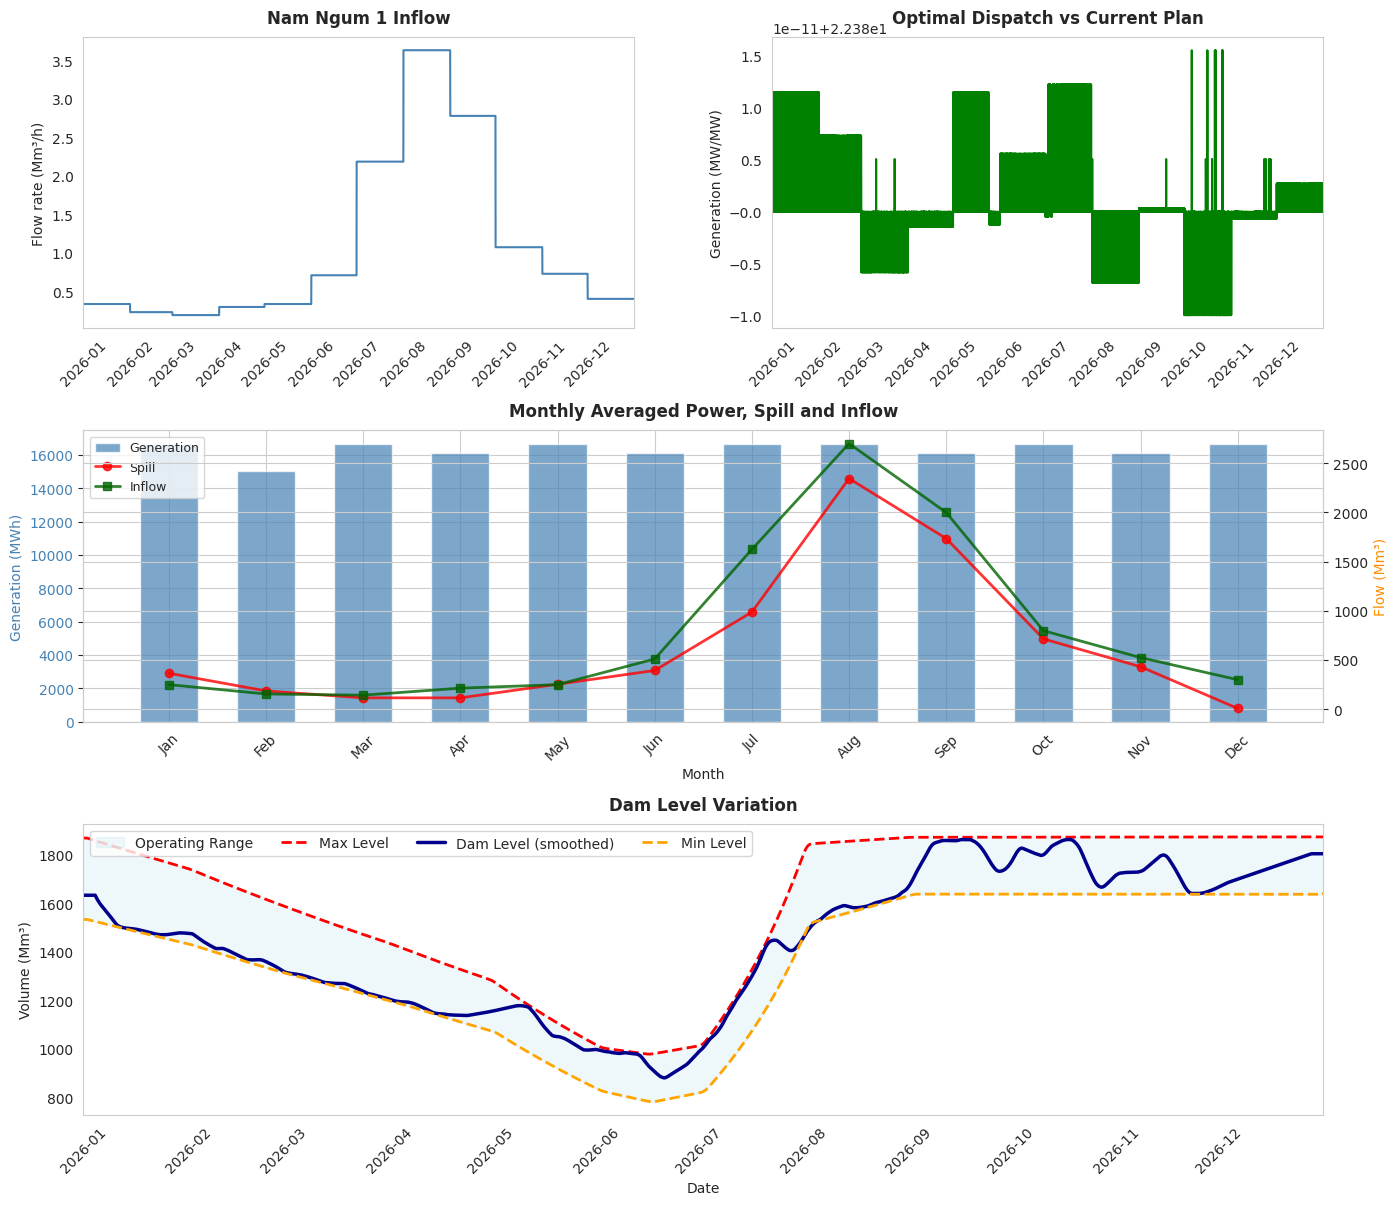

In [18]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
import numpy as np

inflow_data = n.generators.dynamic.p_set

# Rated generation of the turbine process (MW) - scalar for this plant
capacity = (n.processes.static['rate2'] * n.processes.static['p_nom'])[hydroplant_name]

pd.options.plotting.backend = "matplotlib"
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 14)
plt.rcParams['font.size'] = 10

fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.25)

# --- Top-left: Inflow ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(inflow_data.index, inflow_data[inflow_gen].values, linewidth=1.5, color='steelblue')
ax1.set_title('Nam Ngum 1 Inflow', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Flow rate (Mm³/h)', fontsize=10)
ax1.set_xlim(inflow_data.index.min(), inflow_data.index.max())
ax1.grid(False)
ax1.tick_params(axis='x', rotation=45)

# --- Top-right: Optimal Dispatch (moved from full-width row) ---
ax2 = fig.add_subplot(gs[0, 1])
dispatch = df_hydro_power_dispatch['NNg 1 Turbine']
ax2.plot(dispatch.index, dispatch.values, linewidth=1.5, color='green', label='Optimal Dispatch')
ax2.set_title('Optimal Dispatch vs Current Plan', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Generation (MW/MW)', fontsize=10)
ax2.set_xlim(dispatch.index.min(), dispatch.index.max())
ax2.grid(False)
ax2.tick_params(axis='x', rotation=45)
# ax2.legend(loc='best', frameon=True, fontsize=9)

# --- Middle row (full width): Monthly Power, Spill, Inflow (moved from top-right) ---
ax4 = fig.add_subplot(gs[1, :])
ax4_twin = ax4.twinx()

x_pos = np.arange(len(df_hydro_power))
ax4.bar(x_pos, df_hydro_power[hydroplant_name].values, width=0.6, alpha=0.7,
        color='steelblue', label='Generation')
ax4.set_ylabel('Generation (MWh)', fontsize=10, color='steelblue')
ax4.tick_params(axis='y', labelcolor='steelblue')

ax4_twin.plot(x_pos, df_spill[spill_name].values, 'o-', linewidth=2, markersize=6,
              color='red', alpha=0.8, label='Spill')
ax4_twin.plot(x_pos, df_inflow[inflow_gen].values, 's-', linewidth=2, markersize=6,
              color='darkgreen', alpha=0.8, label='Inflow')
ax4_twin.set_ylabel('Flow (Mm³)', fontsize=10, color='darkorange')

ax4.set_title('Monthly Averaged Power, Spill and Inflow', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('Month', fontsize=10)
month_labels = [date.strftime('%b') for date in df_hydro_power.index]
ax4.set_xticks(x_pos)
ax4.set_xticklabels(month_labels, rotation=45)

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, fontsize=9)

# --- Bottom row (full width): Dam Level ---
ax5 = fig.add_subplot(gs[2, :])
dam_level_smoothed = df_dam_level[dam_name].rolling(window=168, center=True).mean().bfill().ffill()
e_max = (n.stores.dynamic.e_max_pu * n.stores.static.e_nom)[dam_name].rolling(window=48, center=True).mean().bfill().ffill()
e_min = (n.stores.dynamic.e_min_pu * n.stores.static.e_nom)[dam_name].rolling(window=48, center=True).mean().bfill().ffill()

ax5.fill_between(e_max.index, e_min.values, e_max.values, alpha=0.2, color='lightblue', label='Operating Range')
ax5.plot(e_max.index, e_max.values, linewidth=2, color='red', linestyle='--', label='Max Level')
ax5.plot(dam_level_smoothed.index, dam_level_smoothed.values, linewidth=2.5, color='darkblue', label='Dam Level (smoothed)')
ax5.plot(e_min.index, e_min.values, linewidth=2, color='orange', linestyle='--', label='Min Level')

ax5.set_title('Dam Level Variation', fontsize=12, fontweight='bold', pad=10)
ax5.set_xlabel('Date', fontsize=10)
ax5.set_ylabel('Volume (Mm³)', fontsize=10)
ax5.set_xlim(e_max.index.min(), e_max.index.max())
ax5.grid(False)
ax5.legend(loc='upper left', frameon=True, fontsize=10, ncol=4)
ax5.tick_params(axis='x', rotation=45)

fig.subplots_adjust(hspace=0.35, wspace=0.25)
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

The clone worked. Now let me extract the notebook's structure and results.## ພາບລວມຂອງແບບຈຳລອງ

Notebook ນີ້ແມ່ນ Exercise 4: Dam Management — ການຈຳລອງການບໍລິຫານອ່າງເກັບນ້ຳ ເຂື່ອນນ້ຳງື່ມ 1 (Nam Ngum 1) ດ້ວຍ PyPSA ໂດຍໃຊ້ການ optimize ແບບ Linear/MILP (solver HiGHS) ໄລຍະ 1 ປີ, 8,760 ຊົ່ວໂມງ (ປີ 2026, hourly resolution). ໂຄງສ້າງແບບຈຳລອງ:

- ອ່າງເກັບນ້ຳ (Store): ຄວາມຈຸ 2,700 Mm³, ລະດັບເລີ່ມຕົ້ນ 1,750 Mm³, ມີເສັ້ນກົດລະດັບນ້ຳສູງສຸດ/ຕ່ຳສຸດ (rule curve) ປ່ຽນຕາມລະດູ ແລະ ບັງຄັບໃຫ້ທ້າຍປີ ລະດັບນ້ຳ ≥ 1,750 Mm³ (ເທົ່າຕອນເລີ່ມ)
- ກັງຫັນ (Turbine process): ອັດຕາໄຫຼສູງສຸດ 2.1 Mm³/h × ຕົວແປງ 111.9 MW/(Mm³/h) = ກຳລັງຕິດຕັ້ງ ≈ 235 MW, ເປັນແບບ committable (min up 8 h, min down 4 h, p_min 20%)
- ນ້ຳໄຫຼເຂົ້າ (Inflow): ຂໍ້ມູນລາຍຊົ່ວໂມງ — ລະດູແລ້ງ ~0.2–0.4 Mm³/h, ສູງສຸດເດືອນສິງຫາ ~3.6 Mm³/h
- ໂຫຼດ (Load): 250 MW ຄົງທີ່ = 2,190 GWh/ປີ
- Slack Generator (ແຫຼ່ງທົດແທນ/load shedding): ລາຄາ 1,000 $/MWh; ໂຊລາ ແລະ ລົມ ຕັ້ງ p_nom = 0 (ບໍ່ມີບົດບາດໃນ scenario ນີ້)

## ຜົນການຈຳລອງຫຼັກ

ການ optimize ສຳເລັດ (Status: optimal), ຄ່າ objective = 1.27×10⁹ $.

| ຕົວຊີ້ວັດ | ຄ່າ |
|---|---|
| ພະລັງງານໄຟຟ້ານ້ຳຕົກ (NNg 1) | 923,178 MWh/ປີ (42.2% ຂອງໂຫຼດ) |
| ພະລັງງານຈາກ Slack | 1,266,822 MWh/ປີ (57.8%) |
| ຊົ່ວໂມງເດີນເຄື່ອງກັງຫັນ | 4,524 h ຈາກ 8,760 h |
| Capacity Factor ຂອງເຂື່ອນ | ≈ 44.8% |
| ນ້ຳລົ້ນ (Spill) | ເກີດສະເພາະ ສິງຫາ–ກັນຍາ (~800 ແລະ ~550 Mm³) |

## ການຕີຄວາມໝາຍ

1. ຍຸດທະສາດການບໍລິຫານນ້ຳ: optimizer ພະຍາຍາມໃຊ້ນ້ຳໃຫ້ຄຸ້ມທີ່ສຸດ ເພື່ອຫຼີກລ່ຽງ Slack ທີ່ແພງ (1,000 $/MWh). ຈຶ່ງເຫັນຮູບແບບ: ດຶງລະດັບນ້ຳລົງເລື້ອຍໆ ຈາກ ມັງກອນ→ມິຖຸນາ (ຈາກ ~1,750 ລົງເຖິງ ~800 Mm³ ຕິດເສັ້ນຕ່ຳສຸດ) → ເຕີມກັບຄືນໄວໃນ ກໍລະກົດ–ສິງຫາ ຈາກນ້ຳລະດູຝົນ → ຮັກສາລະດັບສູງ ກັນຍາ–ທັນວາ ເພື່ອບັນລຸເງື່ອນໄຂທ້າຍປີ.

2. ເປັນຫຍັງຈຶ່ງມີ Spill ທັງທີ່ໄຟບໍ່ພໍ: ໃນເດືອນສິງຫາ ນ້ຳໄຫຼເຂົ້າສູງສຸດ 3.6 Mm³/h ແຕ່ກັງຫັນຮັບໄດ້ພຽງ 2.1 Mm³/h ແລະ ອ່າງກໍໃກ້ເຕັມ (ຕິດເສັ້ນສູງສຸດ) — ນ້ຳສ່ວນເກີນຈຶ່ງຕ້ອງລົ້ນອອກ. ສັງເກດວ່າເດືອນສິງຫາ ຜະລິດໄດ້ ~175 GWh ≈ 235 MW × 744 h ຄືແລ່ນເຕັມກຳລັງເກືອບຕະຫຼອດເດືອນແລ້ວ ກໍຍັງລົ້ນ. ນ້ຳລົ້ນ ~1,350 Mm³ ນີ້ທຽບເທົ່າພະລັງງານທີ່ເສຍໄປ ≈ 150 GWh.

3. ຮູບແບບ dispatch ເປັນ block on/off: ເພາະກັງຫັນຖືກຕັ້ງເປັນ committable ທີ່ມີ min up/down time — ໃນລະດູແລ້ງມັນຈຶ່ງເປີດ-ປິດເປັນຊ່ວງເພື່ອປະຢັດນ້ຳ ແທນທີ່ຈະແລ່ນຕໍ່າຕໍ່ເນື່ອງ, ສ່ວນ ກໍລະກົດ–ກັນຍາ ແລ່ນເຕັມ 235 MW ຕໍ່ເນື່ອງ.

4. ຂໍ້ສະຫຼຸບເຊີງລະບົບ: ເຂື່ອນດຽວ (235 MW, CF ~45%) ບໍ່ສາມາດຮັບໂຫຼດຖານ 250 MW ໄດ້ — ຂາດພະລັງງານ ~58% ທີ່ຕ້ອງມາຈາກແຫຼ່ງອື່ນ. ນີ້ຄືເຫດຜົນທີ່ notebook ວາງ placeholder ໂຊລາ/ລົມ ໄວ້ ເພື່ອໃຫ້ທົດລອງເພີ່ມກຳລັງຕິດຕັ້ງໃນ exercise ຕໍ່ໄປ.

## ການກວດສອບຄວາມສອດຄ່ອງ (ຂ້ອຍກວດແລ້ວ)

Objective 1.27×10⁹ = 1,266,822 MWh × 1,000 $/MWh ✓ · ຜົນລວມການຜະລິດ = 2,190,000 MWh = 250 MW × 8,760 h ✓ · ກຳລັງສູງສຸດທີ່ dispatch ຈິງ 235.0 MW = 2.1 × 111.9 ✓ · ຕົວເລກ 235 MW ກົງກັບກຳລັງຕິດຕັ້ງຈິງຂອງນ້ຳງື່ມ 1 ຫຼັງຂະຫຍາຍ (155 MW + 2×40 MW).

ໝາຍເຫດ: ຮູບຜົນການຈຳລອງ (4 panel) ທີ່ສະກັດຈາກ notebook ບັນທຶກໄວ້ໃຫ້ແລ້ວຂ້າງເທິງ. ຄ່າ spill ລາຍເດືອນແມ່ນອ່ານຈາກກຣາຟ (ໂດຍປະມານ) ເພາະຕົວເລກດິບບໍ່ໄດ້ຝັງໃນ output — ຖ້າຕ້ອງການຄ່າແນ່ນອນ ຕ້ອງ run notebook ແລ້ວ export `df_spill` ອອກມາ.

Sources: [notebook_exercise_4.ipynb (GitHub)](https://github.com/PriyeshGosai/energylab-emw-2026/blob/main/notebook_exercise_4.ipynb)